<a href="https://colab.research.google.com/github/ravideltech/Quantium-Data-Analytics-Virtual-Experience/blob/main/Quantiumtask1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Show all columns
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [7]:
transactions = pd.read_excel("QVI_transaction_data.xlsx")
customers = pd.read_csv("QVI_purchase_behaviour.csv")

print("Transaction Shape:", transactions.shape)
print("Customer Shape:", customers.shape)

Transaction Shape: (264836, 8)
Customer Shape: (72637, 3)


In [8]:
transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [9]:
customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [11]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [12]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [13]:
transactions.isnull().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0


In [14]:
customers.isnull().sum()

,0
LYLTY_CARD_NBR,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


In [15]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [16]:
transactions["PROD_NAME"].head(10)

,PROD_NAME
0,Natural Chip Compny SeaSalt175g
1,CCs Nacho Cheese 175g
2,Smiths Crinkle Cut Chips Chicken 170g
3,Smiths Chip Thinly S/Cream&Onion 175g
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g
5,Old El Paso Salsa Dip Tomato Mild 300g
6,Smiths Crinkle Chips Salt & Vinegar 330g
7,Grain Waves Sweet Chilli 210g
8,Doritos Corn Chip Mexican Jalapeno 150g
9,Grain Waves Sour Cream&Chives 210G


In [17]:
transactions["PROD_NAME"].sample(10, random_state=42)

,PROD_NAME
147374,Red Rock Deli Thai Chilli&Lime 150g
18693,Pringles Chicken Salt Crips 134g
98522,Tyrrells Crisps Ched & Chives 165g
65042,Infuzions Mango Chutny Papadums 70g
176861,Twisties Chicken270g
230260,Cheezels Cheese Box 125g
42236,Doritos Salsa Mild 300g
100479,Grain Waves Sour Cream&Chives 210G
5902,Twisties Cheese Burger 250g
173945,Smiths Crinkle Cut Chips Chs&Onion170g


In [18]:
transactions["PACK_SIZE"] = (
    transactions["PROD_NAME"]
    .str.extract(r"(\d+)")[0]
    .astype(int)
)

transactions[["PROD_NAME", "PACK_SIZE"]].head()

,PROD_NAME,PACK_SIZE
0,Natural Chip Compny SeaSalt175g,175
1,CCs Nacho Cheese 175g,175
2,Smiths Crinkle Cut Chips Chicken 170g,170
3,Smiths Chip Thinly S/Cream&Onion 175g,175
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150


In [19]:
transactions["BRAND"] = transactions["PROD_NAME"].str.split().str[0]

transactions[["PROD_NAME", "BRAND"]].head()

,PROD_NAME,BRAND
0,Natural Chip Compny SeaSalt175g,Natural
1,CCs Nacho Cheese 175g,CCs
2,Smiths Crinkle Cut Chips Chicken 170g,Smiths
3,Smiths Chip Thinly S/Cream&Onion 175g,Smiths
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle


In [20]:
data = pd.merge(
    transactions,
    customers,
    on="LYLTY_CARD_NBR",
    how="left"
)

print(data.shape)
data.head()

(264836, 12)


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATE              264836 non-null  int64  
 1   STORE_NBR         264836 non-null  int64  
 2   LYLTY_CARD_NBR    264836 non-null  int64  
 3   TXN_ID            264836 non-null  int64  
 4   PROD_NBR          264836 non-null  int64  
 5   PROD_NAME         264836 non-null  object 
 6   PROD_QTY          264836 non-null  int64  
 7   TOT_SALES         264836 non-null  float64
 8   PACK_SIZE         264836 non-null  int64  
 9   BRAND             264836 non-null  object 
 10  LIFESTAGE         264836 non-null  object 
 11  PREMIUM_CUSTOMER  264836 non-null  object 
dtypes: float64(1), int64(7), object(4)
memory usage: 24.2+ MB


In [23]:
data.isnull().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
PACK_SIZE,0
BRAND,0


In [24]:
sales_lifestage = data.groupby("LIFESTAGE")["TOT_SALES"].sum().sort_values(ascending=False)

sales_lifestage

,TOT_SALES
LIFESTAGE,
OLDER SINGLES/COUPLES,402426.75
RETIREES,366470.90
OLDER FAMILIES,353767.20
YOUNG FAMILIES,316160.10
YOUNG SINGLES/COUPLES,260405.30
MIDAGE SINGLES/COUPLES,184751.30
NEW FAMILIES,50433.45


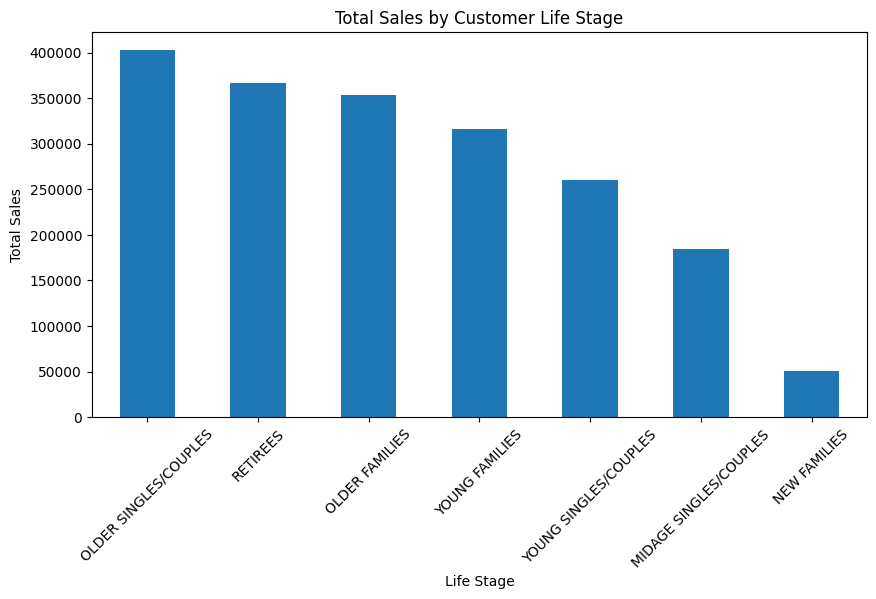

In [25]:
import matplotlib.pyplot as plt

sales_lifestage.plot(kind="bar", figsize=(10,5))

plt.title("Total Sales by Customer Life Stage")
plt.xlabel("Life Stage")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [26]:
sales_premium = data.groupby("PREMIUM_CUSTOMER")["TOT_SALES"].sum()

sales_premium

,TOT_SALES
PREMIUM_CUSTOMER,
Budget,676211.55
Mainstream,750744.50
Premium,507458.95


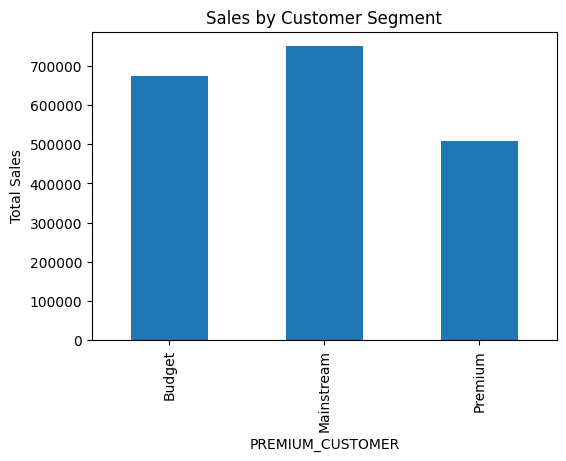

In [27]:
sales_premium.plot(kind="bar", figsize=(6,4))

plt.title("Sales by Customer Segment")
plt.ylabel("Total Sales")
plt.show()

In [28]:
brand_sales = data.groupby("BRAND")["TOT_SALES"].sum().sort_values(ascending=False)

brand_sales.head(10)

,TOT_SALES
BRAND,
Kettle,390239.8
Smiths,210076.8
Doritos,201538.9
Pringles,177655.5
Old,90785.1
Thins,88852.5
Twisties,81522.1
Tostitos,79789.6
Infuzions,76247.6


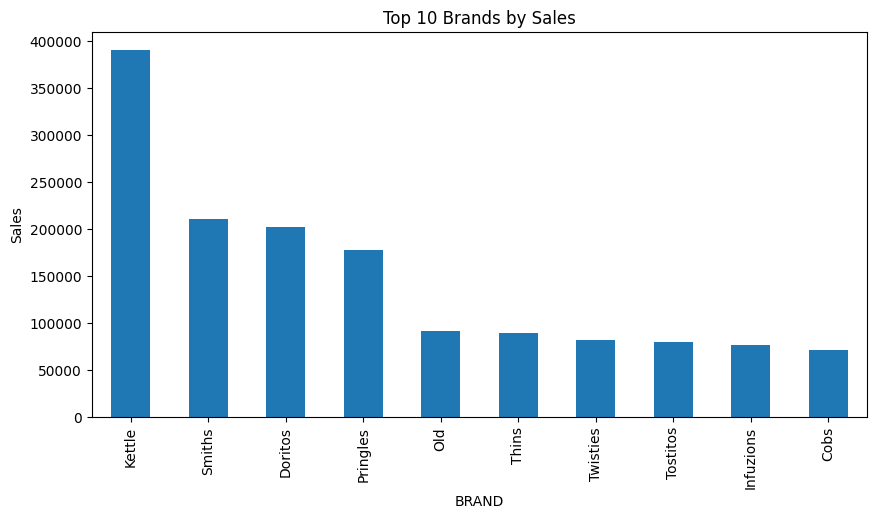

In [29]:
brand_sales.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Brands by Sales")
plt.ylabel("Sales")
plt.show()

In [30]:
pack_sales = data.groupby("PACK_SIZE")["TOT_SALES"].sum().sort_values(ascending=False)

pack_sales.head(10)

,TOT_SALES
PACK_SIZE,
175,485437.4
150,304288.5
134,177655.5
110,162765.4
170,146673.0
330,136794.3
300,113330.6
165,101360.6
380,76719.6


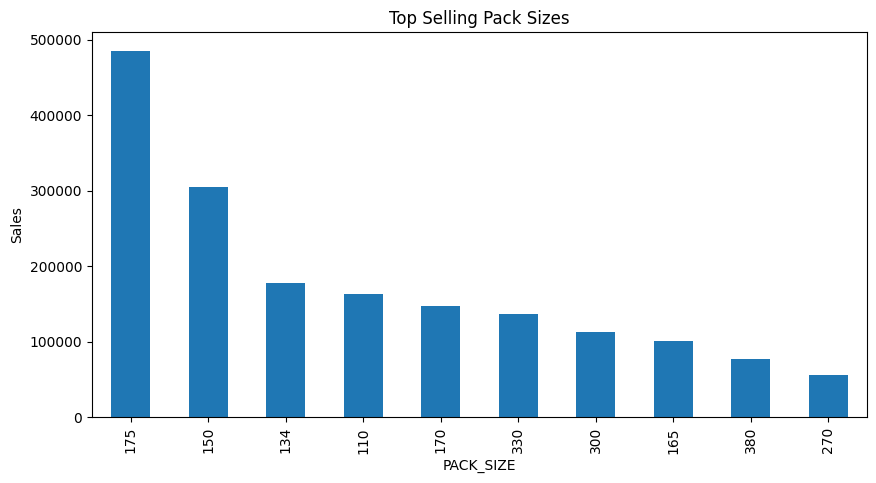

In [31]:
pack_sales.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top Selling Pack Sizes")
plt.ylabel("Sales")
plt.show()

In [32]:
avg_spend = data.groupby("LIFESTAGE")["TOT_SALES"].mean().sort_values(ascending=False)

avg_spend

,TOT_SALES
LIFESTAGE,
OLDER SINGLES/COUPLES,7.386823
RETIREES,7.364325
MIDAGE SINGLES/COUPLES,7.357678
NEW FAMILIES,7.289124
OLDER FAMILIES,7.279760
YOUNG FAMILIES,7.252709
YOUNG SINGLES/COUPLES,7.158515


In [33]:
avg_qty = data.groupby("LIFESTAGE")["PROD_QTY"].mean().sort_values(ascending=False)

avg_qty

,PROD_QTY
LIFESTAGE,
OLDER FAMILIES,1.954729
YOUNG FAMILIES,1.939828
OLDER SINGLES/COUPLES,1.912719
MIDAGE SINGLES/COUPLES,1.900478
RETIREES,1.892289
NEW FAMILIES,1.856771
YOUNG SINGLES/COUPLES,1.831762


In [34]:
segment_sales = data.groupby(
    ["LIFESTAGE", "PREMIUM_CUSTOMER"]
)["TOT_SALES"].sum().sort_values(ascending=False)

segment_sales

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Budget              168363.25
YOUNG SINGLES/COUPLES   Mainstream          157621.60
RETIREES                Mainstream          155677.05
YOUNG FAMILIES          Budget              139345.85
OLDER SINGLES/COUPLES   Budget              136769.80
                        Mainstream          133393.80
                        Premium             132263.15
RETIREES                Budget              113147.80
OLDER FAMILIES          Mainstream          103445.55
RETIREES                Premium              97646.05
YOUNG FAMILIES          Mainstream           92788.75
MIDAGE SINGLES/COUPLES  Mainstream           90803.85
YOUNG FAMILIES          Premium              84025.50
OLDER FAMILIES          Premium              81958.40
YOUNG SINGLES/COUPLES   Budget               61141.60
MIDAGE SINGLES/COUPLES  Premium              58432.65
YOUNG SINGLES/COUPLES   Premium              41642.10
MIDAGE SINGLES/COUPLES  Budget               35514.80
NEW FAMILIES            Budget               21928.45
                        Mainstream           17013.90
                        Premium              11491.10
Name: TOT_SALES, dtype: float64

In [35]:
data["DATE"] = pd.to_datetime(
    data["DATE"],
    origin="1899-12-30",
    unit="D"
)

data["DATE"].head()

,DATE
0,2018-10-17
1,2019-05-14
2,2019-05-20
3,2018-08-17
4,2018-08-18


In [36]:
data[data["PROD_QTY"] > 5]
data[data["PROD_QTY"] > 5].shape
data = data[data["PROD_QTY"] <= 5]

In [37]:
segment_transactions = data.groupby(
    ["LIFESTAGE", "PREMIUM_CUSTOMER"]
).size().sort_values(ascending=False)

segment_transactions

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Budget              23160
RETIREES                Mainstream          21466
YOUNG SINGLES/COUPLES   Mainstream          20854
YOUNG FAMILIES          Budget              19122
OLDER SINGLES/COUPLES   Budget              18407
                        Mainstream          18318
                        Premium             17754
RETIREES                Budget              15201
OLDER FAMILIES          Mainstream          14244
RETIREES                Premium             13096
YOUNG FAMILIES          Mainstream          12907
MIDAGE SINGLES/COUPLES  Mainstream          11874
YOUNG FAMILIES          Premium             11563
OLDER FAMILIES          Premium             11190
YOUNG SINGLES/COUPLES   Budget               9242
MIDAGE SINGLES/COUPLES  Premium              8216
YOUNG SINGLES/COUPLES   Premium              6281
MIDAGE SINGLES/COUPLES  Budget               5020
NEW FAMILIES            Budget               3005
                        Mainstream           2325
                        Premium              1589
dtype: int64

In [38]:
segment_avg = data.groupby(
    ["LIFESTAGE", "PREMIUM_CUSTOMER"]
)["TOT_SALES"].mean().sort_values(ascending=False)

segment_avg

LIFESTAGE               PREMIUM_CUSTOMER
MIDAGE SINGLES/COUPLES  Mainstream          7.647284
YOUNG SINGLES/COUPLES   Mainstream          7.558339
RETIREES                Premium             7.456174
OLDER SINGLES/COUPLES   Premium             7.449766
RETIREES                Budget              7.443445
OLDER SINGLES/COUPLES   Budget              7.430315
NEW FAMILIES            Mainstream          7.317806
                        Budget              7.297321
YOUNG FAMILIES          Budget              7.287201
OLDER SINGLES/COUPLES   Mainstream          7.282116
OLDER FAMILIES          Budget              7.269570
YOUNG FAMILIES          Premium             7.266756
OLDER FAMILIES          Mainstream          7.262395
RETIREES                Mainstream          7.252262
NEW FAMILIES            Premium             7.231655
OLDER FAMILIES          Premium             7.208079
YOUNG FAMILIES          Mainstream          7.189025
MIDAGE SINGLES/COUPLES  Premium             7.112056
                        Budget              7.074661
YOUNG SINGLES/COUPLES   Premium             6.629852
                        Budget              6.615624
Name: TOT_SALES, dtype: float64

In [39]:
brand_segment = (
    data.groupby(["LIFESTAGE", "BRAND"])["TOT_SALES"]
        .sum()
        .reset_index()
)

brand_segment.head()

,LIFESTAGE,BRAND,TOT_SALES
0,MIDAGE SINGLES/COUPLES,Burger,660.1
1,MIDAGE SINGLES/COUPLES,CCs,1717.8
2,MIDAGE SINGLES/COUPLES,Cheetos,1499.7
3,MIDAGE SINGLES/COUPLES,Cheezels,4080.6
4,MIDAGE SINGLES/COUPLES,Cobs,6995.8


# Business Insights

## Dataset Summary

- The transaction dataset contains 264,836 chip purchases.
- Customer dataset contains 72,637 loyalty customers.
- No missing values were found after merging both datasets.
- Product pack size and brand were successfully extracted from product names.

## Key Findings

### Customer Life Stage

- Older Singles/Couples generated the highest chip sales.
- Retirees were the second highest contributing customer group.
- Older Families also contributed significantly to total revenue.

### Customer Segment

- Mainstream customers generated the highest total sales.
- Budget customers ranked second.
- Premium customers contributed the least overall sales.

### Brand Analysis

- Kettle is the highest selling chip brand.
- Smiths and Doritos are also among the top performing brands.
- These brands contribute a significant share of total sales.

### Pack Size Analysis

- 175g is the most popular pack size.
- 150g is the second most preferred pack size.
- Customers generally prefer medium-sized chip packs.

### Spending Behaviour

- Midage Singles/Couples have the highest average spending per transaction.
- Older Families purchase the largest average quantity of chips.

# Recommendations for Julia (Category Manager)

1. Continue promoting Kettle products as they generate the highest sales.

2. Prioritize inventory for 175g and 150g pack sizes because customer demand is highest.

3. Develop targeted promotions for Older Singles/Couples and Retirees, as they contribute the highest revenue.

4. Mainstream customers should remain the primary target for marketing campaigns since they generate the largest sales.

5. Offer bundle discounts on popular brands to increase basket size.

6. Use loyalty promotions for Budget customers to encourage repeat purchases.